In [53]:
%reload_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt
from vrAnalysis.sessions import B2Session
from vrAnalysis.helpers import edge2center
from vrAnalysis.database import get_database
from dimensionality_manuscript.figure_scripts.figure1 import (
    example_placefield,
    example_r2_placefield,
    example_traversal,
    stacked_raster_plot,
)
from dimensionality_manuscript.configs import PFPredQualityConfig
from dimensionality_manuscript import ResultsStore, ResultsAggregator

sessiondb = get_database("vrSessions")
sessions = sessiondb.iter_sessions(imaging=True)
cfg = PFPredQualityConfig()
store = ResultsStore()
results = ResultsAggregator(cfg, store, sessions)

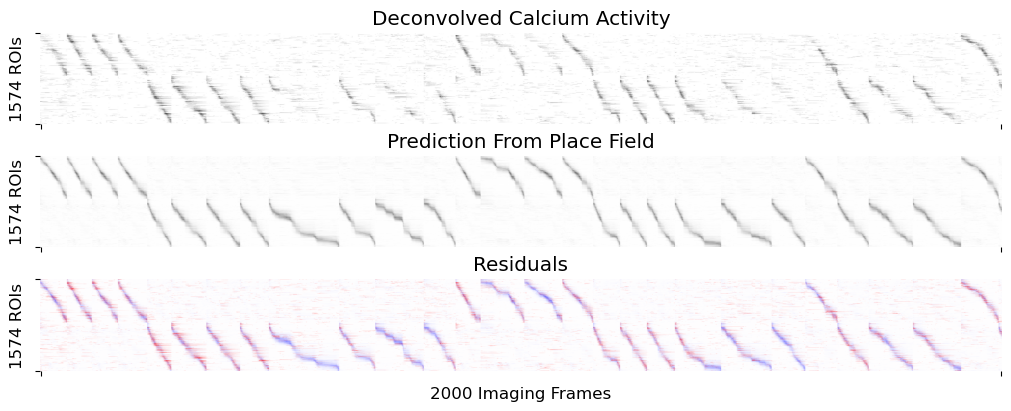

In [31]:
mouse_name = "ATL027"
date = "2023-07-27"
session_id = "701"
spks_type = "sigrebase"
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

fig = stacked_raster_plot(session, prediction_from="placefield", figsize=(10, 4))

c:\Users\Andrew\AppData\Local\miniforge3\envs\vrAnalysis\Lib\site-packages\syd\support.py:162: ParameterUpdateWarning: Warning updating SelectionParameter parameter 'roi': Value 0 not in options, setting to first option (96)
  warn(ParameterUpdateWarning(parameter_name, parameter_type, message))


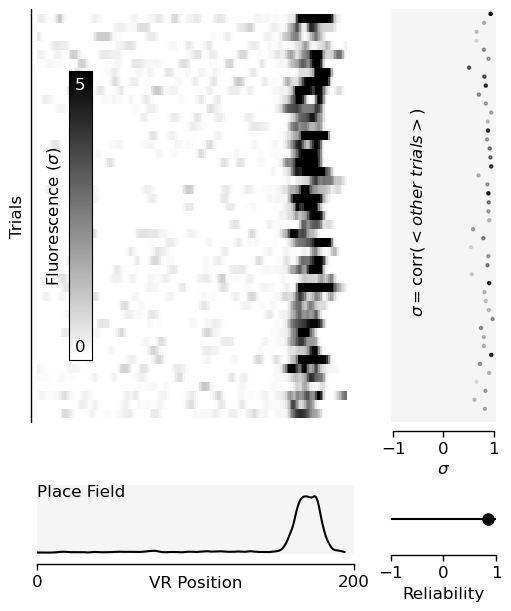

In [32]:
mouse_name = "ATL027"
date = "2023-07-27"
session_id = "701"
spks_type = "oasis"
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

fig = example_placefield(session, 96, 0)

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure1.py:215: RuntimeWarning: Mean of empty slice
  
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure1.py:216: RuntimeWarning: Mean of empty slice
  ax_placefield.plot(placefield, color="k", linewidth=1.5)


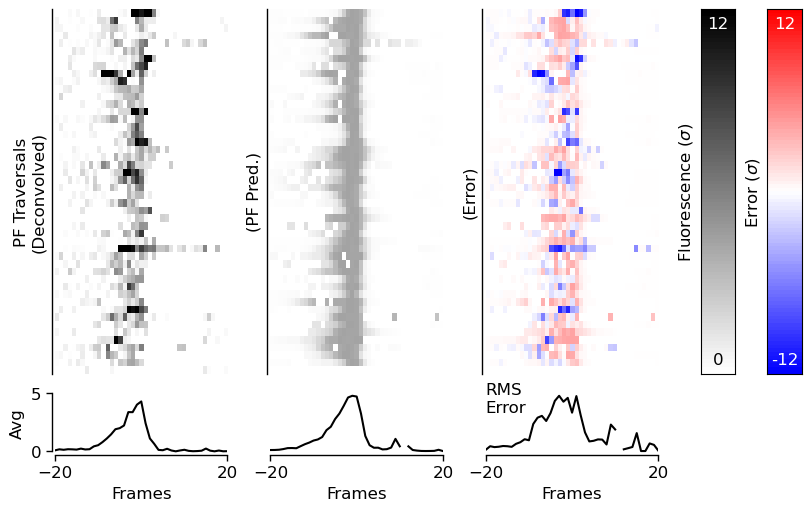

In [33]:
mouse_name = "ATL027"
date = "2023-07-27"
session_id = "701"
spks_type = "oasis"
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

fig = example_traversal(session, roi=96, env=0)


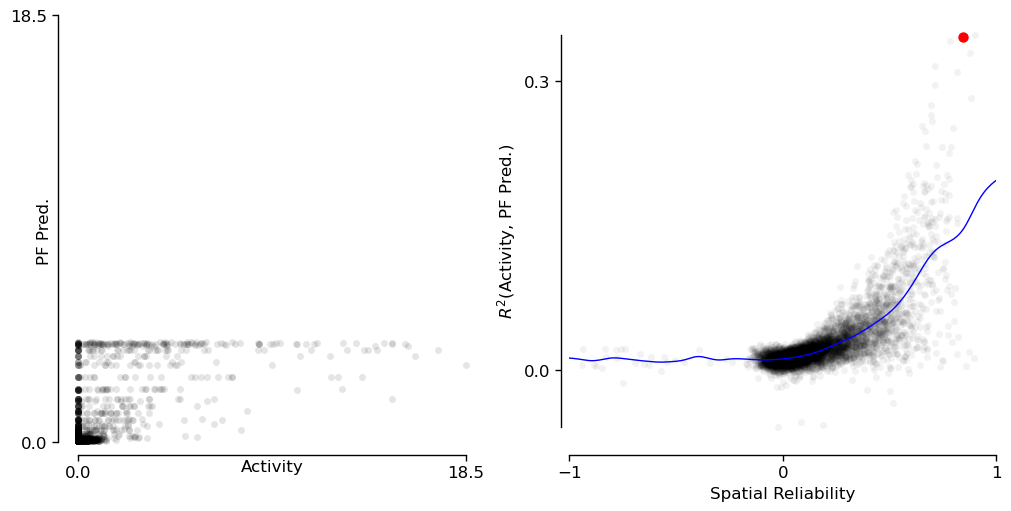

In [67]:
mouse_name = "ATL027"
date = "2023-07-27"
session_id = "701"
spks_type = "oasis"
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

fig = example_r2_placefield(session, roi=96, idx_env=0, cloud_style="scatter", cloud_alpha=0.05, hex_count_norm="log")


In [47]:
results_average = results.average_by_mouse()
out = results_average.sel()

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:695: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mask], axis=0)


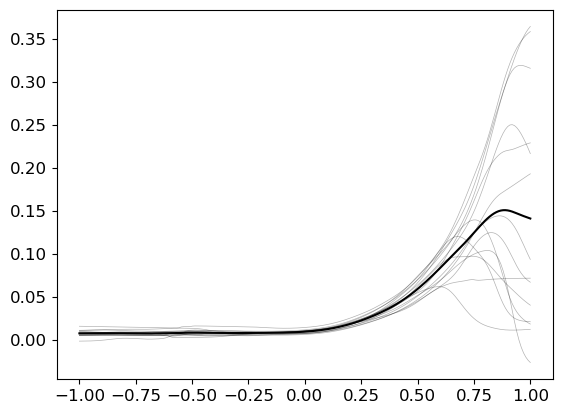

In [57]:
spks_type = "oasis"
idx = results.param_axes["spks_type"].index(spks_type)
hist_centers = edge2center(cfg.bin_edges)
plt.close('all')
plt.plot(out["r2_kde_grid"][0, idx], out["r2_kde_mean"][:, idx].T, color=("k", 0.3), linewidth=0.5)
plt.plot(out["r2_kde_grid"][0, idx], np.nanmean(out["r2_kde_mean"][:, idx], axis=0), color="k", linewidth=1.5)
plt.show()